## Similitud - Firmas MinHash

Se calcula una firma MinHash por proceso a partir de la columna `shingles` (k=5) de `data/final/`

- Hashes `(a·x + b) mod p` como en lab3.1/3.2; cada shingle se codifica con `xxhash64` (nativo en Spark) en vez de `blake2b`

- La firma de `T` enteros reemplaza al conjunto de shingles para estimar Jaccard

### Imports

In [1]:
import os, socket, sys, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes

In [ ]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
final_dir = proyecto / "data" / "final"
out_dir = proyecto / "02_Similitud" / "temp" / "a_firmas_minhash"
out_dir.mkdir(parents=True, exist_ok=True)
firmas_dir = out_dir / "firmas"

- Funciones

Parámetros y funciones compartidas de `02_Similitud/funciones.ipynb`

In [ ]:
ruta_funciones = str(proyecto / "02_Similitud" / "funciones.ipynb")
%run $ruta_funciones

- Spark

In [3]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("similitud-firmas")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))     # 4g (vs 2g en 05): firmas/vectores y joins por pares pesan más que canastas
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")                                   # ~231k filas: 24 tareas bastan, las 200 por defecto quedarían casi vacías
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [4]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 2.0 GB
UI del job    : http://localhost:4040


---
### 1. Carga de data

Spark lee las carpetas `anio=*/mes=*` de `data/final/` como columnas de partición; se filtra por `ANIOS` y se revisan los shingles

In [5]:
assert final_dir.exists(), f"No se encuentra {final_dir}; corre 01_EDA_KDD/KDD/a_transformaciones.ipynb"
print(f"Particiones en disco: {len(list(final_dir.glob('anio=*/mes=*')))} carpetas anio=/mes=")

procesos = spark.read.parquet(str(final_dir)).select(*COLS_SIMILITUD).where(F.col("anio").isin(ANIOS))
N = procesos.count()
print(f"Procesos: {N:,}")

procesos.groupBy("anio").count().orderBy("anio").show()
(procesos.select(F.size("shingles").alias("n"))
         .select(F.min("n").alias("min_shingles"), F.expr("percentile_approx(n, 0.5)").alias("mediana"),
                 F.max("n").alias("max"), F.sum((F.col("n") == 0).cast("int")).alias("vacios")).show())
procesos.select("ocid", "entidad", F.slice("shingles", 1, 6).alias("shingles (6 primeros)")).show(3, truncate=60)

Particiones en disco: 36 carpetas anio=/mes=
Procesos: 231,171
+----+-----+
|anio|count|
+----+-----+
|2023|74789|
|2024|78699|
|2025|77683|
+----+-----+

+------------+-------+----+------+
|min_shingles|mediana| max|vacios|
+------------+-------+----+------+
|           9|    185|4895|     0|
+------------+-------+----+------+

+---------------------------+-----------------------------------+------------------------------------------+
|                       ocid|                            entidad|                     shingles (6 primeros)|
+---------------------------+-----------------------------------+------------------------------------------+
|ocds-dgv273-seacev3-1085359|            PETROLEOS DEL PERU S.A.|[adqui, dquis, quisi, uisic, isici, sicio]|
|ocds-dgv273-seacev3-1090383|MUNICIPALIDAD DISTRITAL DE LIVITACA|[contr, ontra, ntrat, trata, ratac, ataci]|
|ocds-dgv273-seacev3-1092010|            ZONA ARQUEOLOGICA CARAL|[contr, ontra, ntrat, trata, ratac, ataci]|
+--------------

### 2. Coeficientes

`T` pares `(a, b)` generados con `SEED`, uno por función hash

In [6]:
A_COEF, B_COEF = generar_coeficientes()
print(f"t = {T} | p = {P}")
print("a[:5] =", A_COEF[:5].tolist(), "| b[:5] =", B_COEF[:5].tolist())

t = 100 | p = 2147483647
a[:5] = [191664964, 1662057957, 1405681632, 942484272, 929893138] | b[:5] = [1788288545, 429299595, 1728507682, 15810353, 1711206423]


### 3. Escritura de firmas

- Se calculan una sola vez para los 3 años y se escriben en `temp/a_firmas_minhash/firmas`, particionadas por `anio`/`mes`

- Si ya existen se reutilizan (`RECALCULAR = True` para rehacerlas)

In [7]:
RECALCULAR = False         # reutiliza las firmas si ya existen (~139 s); True para rehacerlas

if RECALCULAR or not firmas_dir.exists():
    t0 = time.time()
    firmas = firmar(codificar_shingles(procesos.select("ocid", "entidad", "fecha", "anio", "mes", "shingles")), A_COEF, B_COEF)
    (firmas.select("ocid", "entidad", "fecha", "firma", "anio", "mes")
           .write.mode("overwrite").partitionBy("anio", "mes").parquet(str(firmas_dir)))
    print(f"Firmas guardadas en {time.time() - t0:,.0f} s")
else:
    print("Firmas ya existen; se reutilizan")

firmas = spark.read.parquet(str(firmas_dir))

Firmas guardadas en 139 s


#### a. Verificación

Mismo nº de filas que `data/final/`, largo `T`, sin nulos y mismas particiones

In [8]:
n_firmas = firmas.count()
chk = firmas.select(F.min(F.size("firma")).alias("lmin"), F.max(F.size("firma")).alias("lmax"),
                    F.sum(F.col("firma").isNull().cast("int")).alias("nulos")).first()
mb = sum(f.stat().st_size for f in firmas_dir.rglob("*.parquet")) / 1024**2
print(f"Firmas: {n_firmas:,} (procesos: {N:,}) | largo {chk['lmin']}–{chk['lmax']} | nulos {chk['nulos']} | {mb:,.1f} MB | "
      f"{len(list(firmas_dir.glob('anio=*/mes=*')))} particiones")
assert n_firmas == N and chk["lmin"] == T == chk["lmax"] and chk["nulos"] == 0

firmas.printSchema()
firmas.select("ocid", F.slice("firma", 1, 5).alias("firma (5 primeros)")).show(3, truncate=False)

Firmas: 231,171 (procesos: 231,171) | largo 100–100 | nulos 0 | 63.6 MB | 36 particiones
root
 |-- ocid: string (nullable = true)
 |-- entidad: string (nullable = true)
 |-- fecha: timestamp (nullable = true)
 |-- firma: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- anio: integer (nullable = true)
 |-- mes: integer (nullable = true)

+---------------------------+--------------------------------------------------+
|ocid                       |firma (5 primeros)                                |
+---------------------------+--------------------------------------------------+
|ocds-dgv273-seacev3-1000120|[10680693, 1080537, 13886120, 8191746, 3406705]   |
|ocds-dgv273-seacev3-1000518|[19569067, 81193696, 6907553, 20127984, 114781477]|
|ocds-dgv273-seacev3-1000520|[22231844, 26912863, 19265620, 8643102, 3406705]  |
+---------------------------+--------------------------------------------------+
only showing top 3 rows



### 4. MinHash vs. Jaccard

Como en lab3.1: muestra de pares de la misma entidad, Jaccard exacto vs. estimado por la firma. Error teórico `1/(2√T) = 0.05`

Pares: 2,000 | MAE = 0.0268 | teórico 1/(2√t) = 0.0500


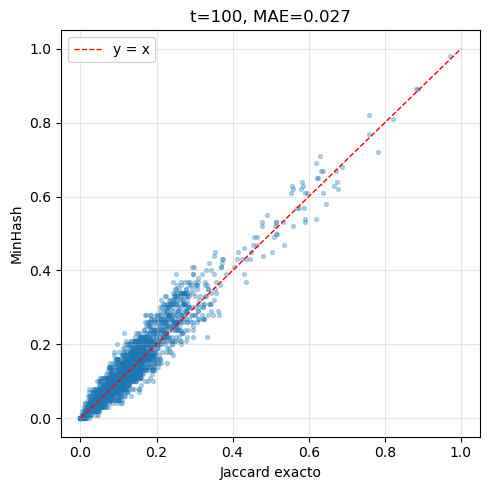

In [9]:
# ~3,000 procesos al azar → pares de la misma entidad; 2,000 pares bastan para estimar el MAE sin un join pesado
muestra = (procesos.join(firmas.select("ocid", "firma"), "ocid").select("ocid", "entidad", "shingles", "firma")
                   .sample(fraction=min(1.0, 3000 / N), seed=SEED))
a, b = muestra.alias("a"), muestra.alias("b")
eval_pd = (a.join(b, (F.col("a.entidad") == F.col("b.entidad")) & (F.col("a.ocid") < F.col("b.ocid")))
            .select(jaccard_exacto(F.col("a.shingles"), F.col("b.shingles")).alias("jaccard"),
                    minhash_sim(F.col("a.firma"), F.col("b.firma")).alias("minhash"))
            .limit(2000).toPandas())
mae = (eval_pd["jaccard"] - eval_pd["minhash"]).abs().mean()
print(f"Pares: {len(eval_pd):,} | MAE = {mae:.4f} | teórico 1/(2√t) = {1 / (2 * np.sqrt(T)):.4f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(eval_pd["jaccard"], eval_pd["minhash"], s=8, alpha=.3)
ax.plot([0, 1], [0, 1], "r--", lw=1, label="y = x")
ax.set_xlabel("Jaccard exacto"); ax.set_ylabel("MinHash"); ax.set_title(f"t={T}, MAE={mae:.3f}"); ax.legend()
plt.tight_layout(); plt.show()

- 231,171 firmas en 139 s, una por proceso, sin nulos

- MAE = 0.027 frente al Jaccard exacto, por debajo del error teórico de 0.05

- Los puntos caen sobre la diagonal: la firma de 100 enteros reemplaza al conjunto de shingles para estimar Jaccard

---
### 5. Cerrar sesión

In [10]:
spark.stop()